In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight


In [2]:
# Dataset and training parameters
DATASET_DIR = "../data/images"

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 20        # Baseline training only
NUM_CLASSES = 6  # cardboard, glass, metal, paper, plastic, trash


In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

print(train_generator.class_indices)


Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [4]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights_dict = dict(enumerate(class_weights))
print(class_weights_dict)


{0: np.float64(1.04437564499484), 1: np.float64(0.8412302576891105), 2: np.float64(1.0284552845528456), 3: np.float64(0.7086834733893558), 4: np.float64(0.8739205526770294), 5: np.float64(3.066666666666667)}


In [5]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)

# Add regularization
x = Dense(256, activation="relu", kernel_regularizer=l2(0.0001))(x)
x = Dropout(0.3)(x)

output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_1              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,301,446 (27.85 MB)

 Trainable params: 905,350 (3.45 MB)

 Non-trainable params: 6,396,096 (24.40 MB)

In [6]:
model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6
)


In [8]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict
)


Epoch 1/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 251s 2s/step - accuracy: 0.3207 - loss: 1.7794 - val_accuracy: 0.5706 - val_loss: 1.3007 - learning_rate: 3.0000e-05
Epoch 2/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.4941 - loss: 1.3579 - val_accuracy: 0.6103 - val_loss: 1.1291 - learning_rate: 3.0000e-05
Epoch 3/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 246s 2s/step - accuracy: 0.5850 - loss: 1.1606 - val_accuracy: 0.6163 - val_loss: 1.0167 - learning_rate: 3.0000e-05
Epoch 4/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - accuracy: 0.6625 - loss: 0.9883 - val_accuracy: 0.6382 - val_loss: 0.9591 - learning_rate: 3.0000e-05
Epoch 5/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 281s 2s/step - accuracy: 0.6868 - loss: 0.9032 - val_accuracy: 0.6839 - val_loss: 0.8744 - learning_rate: 3.0000e-05
Epoch 6/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 219s 2s/step - accuracy: 0.7129 - loss: 0.8416 - val_accuracy: 0.7038 - val_loss: 0.8276 - learning_rate: 3.0000e-05
Epoch 7/20
127/127 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - acc

In [9]:
os.makedirs("../models", exist_ok=True)
model.save("../models/densenet121_regularized.h5")
print("Regularized DenseNet121 model saved.")


Regularized DenseNet121 model saved.


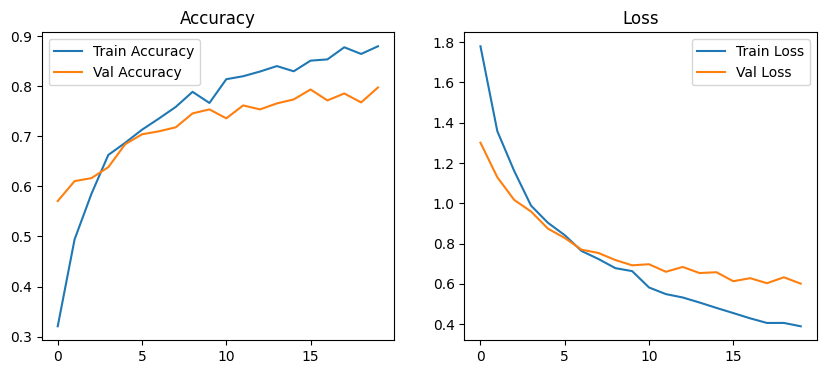

In [10]:
plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss")

plt.show()


In [13]:
# Unfreeze last 30 layers only
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

FINE_TUNE_EPOCHS = 15

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights_dict
)


Epoch 1/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 366s 2s/step - accuracy: 0.8874 - loss: 0.3562 - val_accuracy: 0.7972 - val_loss: 0.5730 - learning_rate: 3.0000e-05
Epoch 2/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 208s 2s/step - accuracy: 0.8839 - loss: 0.3464 - val_accuracy: 0.8072 - val_loss: 0.5736 - learning_rate: 3.0000e-05
Epoch 3/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.8967 - loss: 0.3259 - val_accuracy: 0.7932 - val_loss: 0.5773 - learning_rate: 3.0000e-05
Epoch 4/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.9027 - loss: 0.3079 - val_accuracy: 0.8032 - val_loss: 0.5652 - learning_rate: 9.0000e-06
Epoch 5/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 263s 2s/step - accuracy: 0.9022 - loss: 0.3108 - val_accuracy: 0.7992 - val_loss: 0.5624 - learning_rate: 9.0000e-06
Epoch 6/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.8997 - loss: 0.2979 - val_accuracy: 0.8072 - val_loss: 0.5522 - learning_rate: 9.0000e-06
Epoch 7/15
127/127 ━━━━━━━━━━━━━━━━━━━━ 210s 2s/step - acc

In [15]:
model.save("../models/densenet121_final.keras")
print("Final DenseNet121 model saved.")

Final DenseNet121 model saved.


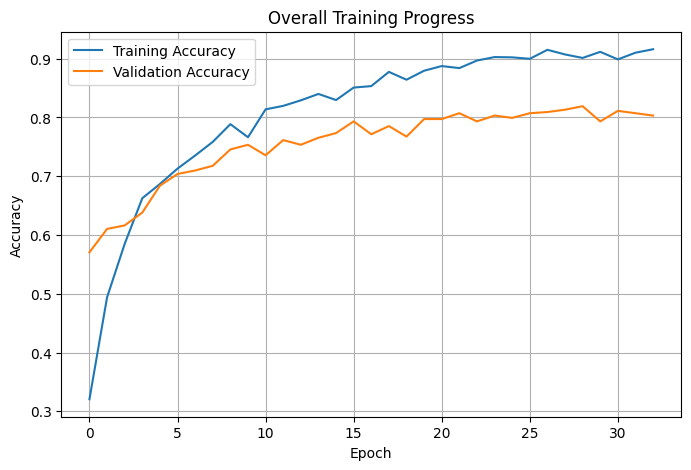

In [16]:
plt.figure(figsize=(8,5))
# Combine histories
train_acc = history.history["accuracy"] + history_finetune.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_finetune.history["val_accuracy"]

plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Overall Training Progress")
plt.legend()
plt.grid(True)

plt.show()


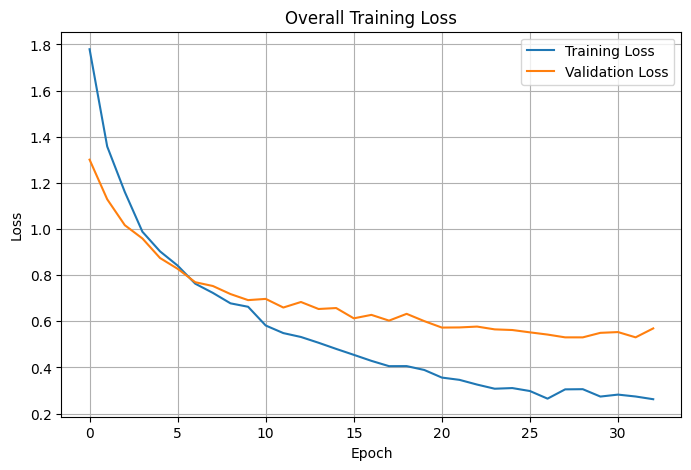

In [17]:
plt.figure(figsize=(8,5))

train_loss = history.history["loss"] + history_finetune.history["loss"]
val_loss = history.history["val_loss"] + history_finetune.history["val_loss"]

plt.plot(train_loss, label="Training Loss")
plt.plot(val_loss, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overall Training Loss")
plt.legend()
plt.grid(True)

plt.show()
